# 1. Why Linear Models Are Limited

> Source: D2L §4.1

# 2. Hidden Layers & Nonlinearity

> Source: D2L §4.1

# 3. Activation Functions

## ReLU

In [13]:
import torch

def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)

x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])
relu(x)


tensor([0., 0., 0., 1., 2.])

# 4. MLP from Scratch

> Source: D2L §4.2

In [14]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

batch_size = 256

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="../data",
    train=True,
    transform=transform,
    download=False
)

test_dataset = datasets.FashionMNIST(
    root="../data",
    train=False,
    transform=transform,
    download=False
)

train_iter = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_iter = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [15]:
num_inputs = 784
num_outputs = 10
num_hiddens = 256

W1 = nn.Parameter(torch.randn(num_inputs,num_hiddens,requires_grad = True)*0.01)
b1 = nn.Parameter(torch.zeros(num_hiddens,requires_grad = True))

W2 = nn.Parameter(torch.randn(num_hiddens,num_outputs,requires_grad = True)*0.01)
b2 = nn.Parameter(torch.zeros(num_outputs,requires_grad = True))

In [23]:
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X,a)

In [24]:
def net(X):
    X = X.reshape((-1,num_inputs))
    H = relu(X @ W1 + b1)
    return H @ W2 + b2

In [25]:
loss = nn.CrossEntropyLoss(reduction='none')

In [26]:
params = [W1, b1, W2, b2]

num_epochs = 10
lr = 0.1

optimizer = torch.optim.SGD(params, lr=lr)

for epoch in range(num_epochs):
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for X, y in train_iter:
        y_hat = net(X)
        l = loss(y_hat, y)

        optimizer.zero_grad()
        l.mean().backward()
        optimizer.step()

        total_loss += l.sum().item()
        total_correct += (y_hat.argmax(dim=1) == y).sum().item()
        total_samples += y.numel()

    train_loss = total_loss / total_samples
    train_acc = total_correct / total_samples

    print(
        f"epoch {epoch+1}, "
        f"loss {train_loss:.4f}, "
        f"train acc {train_acc:.4f}"
    )

epoch 1, loss 1.0412, train acc 0.6411
epoch 2, loss 0.5973, train acc 0.7924
epoch 3, loss 0.5225, train acc 0.8182
epoch 4, loss 0.4801, train acc 0.8320
epoch 5, loss 0.4538, train acc 0.8415
epoch 6, loss 0.4353, train acc 0.8467
epoch 7, loss 0.4201, train acc 0.8527
epoch 8, loss 0.4048, train acc 0.8579
epoch 9, loss 0.3923, train acc 0.8614
epoch 10, loss 0.3826, train acc 0.8642


In [29]:
def get_fashion_mnist_labels(labels):
    text_labels = [
        't-shirt', 'trouser', 'pullover', 'dress', 'coat',
        'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot'
    ]
    return [text_labels[int(i)] for i in labels]

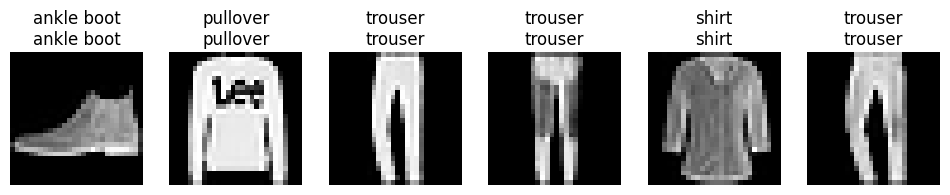

In [31]:
%matplotlib inline
import matplotlib.pyplot as plt

X, y = next(iter(test_iter))

with torch.no_grad():
    y_hat = net(X)
    y_pred = y_hat.argmax(dim=1)

true_labels = get_fashion_mnist_labels(y[:6])
pred_labels = get_fashion_mnist_labels(y_pred[:6])

fig, axes = plt.subplots(1, 6, figsize=(12, 2))

for i in range(6):
    axes[i].imshow(X[i].squeeze(), cmap='gray')
    axes[i].set_title(
        f"{true_labels[i]}\n{pred_labels[i]}"
    )
    axes[i].axis('off')

plt.show()

# 5. PyTorch Concise MLP

> Source: D2L §4.3

In [32]:
import torch
from torch import nn

net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784,256),
    nn.ReLU(),
    nn.Linear(256,10)
)

def init_weights(m):
    if (type(m) == nn.Linear):
        nn.init.normal_(m.weight, std = 0.01)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=10, bias=True)
)

In [34]:
batch_size, lr, num_epoches = 256, 0.1, 10

loss = nn.CrossEntropyLoss()
trainer = torch.optim.SGD(net.parameters(), lr=lr)

# 保存每个 epoch 的结果
train_loss_history = []
train_acc_history = []
test_acc_history = []

for epoch in range(num_epochs):

    net.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for X, y in train_iter:

        y_hat = net(X)
        l = loss(y_hat, y)

        trainer.zero_grad()
        l.backward()
        trainer.step()

        total_loss += l.item() * y.numel()
        total_correct += (y_hat.argmax(dim=1) == y).sum().item()
        total_samples += y.numel()

    train_loss = total_loss / total_samples
    train_acc = total_correct / total_samples

    # 测试
    net.eval()

    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for X, y in test_iter:
            y_hat = net(X)

            test_correct += (
                y_hat.argmax(dim=1) == y
            ).sum().item()

            test_total += y.numel()

    test_acc = test_correct / test_total

    # 保存结果
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)

    print(
        f"epoch {epoch + 1}, "
        f"loss {train_loss:.4f}, "
        f"train acc {train_acc:.4f}, "
        f"test acc {test_acc:.4f}"
    )

epoch 1, loss 1.0401, train acc 0.6413, test acc 0.7279
epoch 2, loss 0.6009, train acc 0.7891, test acc 0.8032
epoch 3, loss 0.5189, train acc 0.8179, test acc 0.7979
epoch 4, loss 0.4778, train acc 0.8330, test acc 0.8159
epoch 5, loss 0.4540, train acc 0.8403, test acc 0.8206
epoch 6, loss 0.4354, train acc 0.8449, test acc 0.8352
epoch 7, loss 0.4169, train acc 0.8536, test acc 0.8355
epoch 8, loss 0.4074, train acc 0.8565, test acc 0.8388
epoch 9, loss 0.3906, train acc 0.8623, test acc 0.8215
epoch 10, loss 0.3825, train acc 0.8639, test acc 0.8174


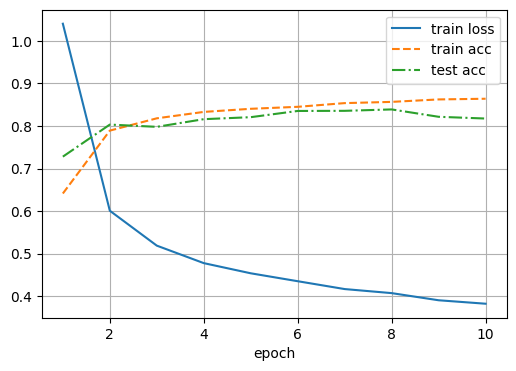

In [35]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))

plt.plot(epochs, train_loss_history, label='train loss')
plt.plot(epochs, train_acc_history, '--', label='train acc')
plt.plot(epochs, test_acc_history, '-.', label='test acc')

plt.xlabel('epoch')
plt.legend()
plt.grid()

plt.show()

# 6. Core Understanding: Forward, Computation Graph and Backpropagation

## Forward Propagation

Forward propagation means computing from input to loss:

X → Linear → ReLU → Linear → logits → CrossEntropyLoss

PyTorch records the operations involved so that gradients can later be computed automatically.

## Computation Graph

The computation graph records how each intermediate tensor depends on previous tensors.

It connects:

input → intermediate values → prediction → loss

and provides the dependency structure required for automatic differentiation.

## Backpropagation

Backpropagation starts from the loss and propagates gradients backward through the computation graph.

Core rule:

- Along one path: local derivatives multiply.
- When multiple paths meet: gradient contributions add.

For a linear layer, the backward pass computes gradients with respect to both:

- the layer parameters;
- the input passed to the previous layer.

`loss.backward()` automatically performs these calculations using the chain rule.

## Key Takeaway

Forward computes the loss.

Backward computes how each parameter contributed to that loss.

Optimizer then uses those gradients to update the parameters.

# 7. Day 3 Summary

## MLP

A multilayer perceptron extends a linear model by inserting hidden layers and nonlinear activation functions.

For Fashion-MNIST:

784 → 256 → 10

The hidden layer learns intermediate features, while the output layer produces class logits.

## Why Nonlinearity Is Necessary

Stacking only linear layers is still equivalent to one linear transformation.

Therefore, nonlinear activation functions such as ReLU are required to increase the expressive power of the network.

ReLU:

ReLU(x) = max(0, x)

## Forward Propagation

Forward propagation computes:

Input → Linear → Activation → Linear → Logits → Loss

During the forward pass, PyTorch builds the computation graph required for automatic differentiation.

## Backpropagation

Backpropagation applies the chain rule from the loss backward through the computation graph.

Core principles:

- Along one path, local derivatives multiply.
- When multiple paths contribute to the same variable, gradient contributions add.

For a linear layer:

y = Wx

the backward rules are:

dW = output_gradient × input^T

d(input) = W^T × output_gradient

For an element-wise activation:

d(input) = output_gradient ⊙ activation'(input)

Therefore, a two-layer MLP backward pass can be understood as repeatedly applying:

Linear backward → Activation backward → Linear backward.

## PyTorch Connection

`loss.backward()` automatically performs these chain-rule calculations and stores the resulting gradients in each trainable parameter's `.grad`.

The optimizer then updates the parameters using those gradients.

## Main Takeaway

Training a neural network follows the pipeline:

Data
→ Forward
→ Loss
→ Backward
→ Gradients
→ Optimizer
→ Updated Parameters

The mathematics of backpropagation is fundamentally the chain rule applied efficiently through a computation graph.